# Final model comparison

This notebook reads existing validation results for XGBoost, AdaBoost,
ElasticNet, GaussianNB, and Ensemble. It does not read the source CSV or
refit any model. Lower misclassification rate is better.

- **v1:** April–May 2024, equal row weights.
- **v2:** March–May 2024, month shares 60% / 30% / 10%.
- **v2 on v1:** the v2 model on April–May 2024, equal row weights.

Compare **v1** with **v2 on v1** for the same evaluation rows. The native
**v2** score uses a different period and weighting. No independent test set
is available. Set a run directory in `RUN_OVERRIDES` when you want to pin a
specific experiment; otherwise the latest run with all three validation
reports is selected for each model family.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

MODELS = ("XGBoost", "AdaBoost", "ElasticNet", "GaussianNB", "Ensemble")
RUN_OVERRIDES = {model: None for model in MODELS}  # Set a run directory to pin it.
CASE_SPECS = {
    "v1": ("v1", "v1", "overall_unweighted", (202404, 202405)),
    "v2": ("v2", "v2", "overall_weighted", (202403, 202404, 202405)),
    "v2 on v1": ("v2", "v1", "overall_unweighted", (202404, 202405)),
}
candidates = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
PROJECT_ROOT = next(
    (path for path in candidates if all((path / model / "outputs").is_dir() for model in MODELS)),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project directory or one of its subdirectories.")

In [2]:
def reports_in_run(run_dir):
    reports = {}
    for metadata_path in sorted((run_dir / "validation").glob("*/validation_metadata.json")):
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        key = (metadata.get("model_experiment"), metadata.get("validation_protocol"))
        if key in {(spec[0], spec[1]) for spec in CASE_SPECS.values()}:
            reports[key] = metadata_path
    return reports


def choose_run(model):
    override = RUN_OVERRIDES[model]
    if override is None:
        runs = sorted((PROJECT_ROOT / model / "outputs").glob("run_*"), reverse=True)
    else:
        run = Path(override)
        runs = [run if run.is_absolute() else PROJECT_ROOT / run]
    required = {(spec[0], spec[1]) for spec in CASE_SPECS.values()}
    for run in runs:
        reports = reports_in_run(run)
        if required.issubset(reports):
            return run, reports
    raise FileNotFoundError(f"No complete v1/v2/v2-on-v1 validation run for {model}.")


records = []
selected_runs = []
source_paths = set()
for model in MODELS:
    run, reports = choose_run(model)
    selected_runs.append({"Model": model, "Run": str(run.relative_to(PROJECT_ROOT))})
    for case, (trained, evaluated, scope, months) in CASE_SPECS.items():
        metadata_path = reports[(trained, evaluated)]
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        metrics = pd.read_csv(metadata_path.with_name("metrics_summary.csv"))
        matching = metrics.loc[metrics["scope"].eq(scope)]
        if len(matching) != 1:
            raise ValueError(f"Expected one {scope} row in {metadata_path.parent}.")
        score = float(matching["misclassification_rate"].iloc[0])
        if (metadata.get("primary_metric") != "misclassification_rate"
                or not np.isclose(float(metadata["classification_threshold"]), 0.5)
                or tuple(metadata["validation_months"]) != months
                or not np.isclose(score, float(metadata["primary_score"]), atol=1e-10)):
            raise ValueError(f"Validation metadata disagrees with metrics in {metadata_path.parent}.")
        shares = metadata.get("validation_month_shares")
        if case == "v2":
            expected = {202403: 0.6, 202404: 0.3, 202405: 0.1}
            if shares is None or {int(key): float(value) for key, value in shares.items()} != expected:
                raise ValueError(f"Unexpected v2 month weights in {metadata_path.parent}.")
        elif shares is not None:
            raise ValueError(f"Unexpected month weights in {metadata_path.parent}.")
        source_paths.add(str(Path(metadata.get("source", metadata.get("data"))).resolve()))
        records.append({"Model": model, "Case": case, "Rows": int(matching["rows"].iloc[0]),
                        "Misclassification rate": score, "Report": str(metadata_path.parent)})

results = pd.DataFrame.from_records(records)
if len(source_paths) != 1:
    raise ValueError("The selected reports refer to different source data files.")
for case in CASE_SPECS:
    if results.loc[results["Case"].eq(case), "Rows"].nunique() != 1:
        raise ValueError(f"The {case} reports contain different row counts.")
if results.loc[results["Case"].eq("v1"), "Rows"].iloc[0] != results.loc[
    results["Case"].eq("v2 on v1"), "Rows"
].iloc[0]:
    raise ValueError("v1 and v2-on-v1 must use the same evaluation rows.")

score_pct = (results.pivot(index="Model", columns="Case", values="Misclassification rate")
             .loc[list(MODELS), list(CASE_SPECS)] * 100)
score_pct["v2 on v1 − v1 (pp)"] = score_pct["v2 on v1"] - score_pct["v1"]
score_pct = score_pct.sort_values("v1")
print("Selected complete runs:")
display(pd.DataFrame(selected_runs))
print("Misclassification rate (%); lower is better:")
display(score_pct.round(3))

Selected complete runs:


Model,Run
XGBoost,XGBoost/outputs/run_20261006_152724
AdaBoost,AdaBoost/outputs/run_20261006_162524
ElasticNet,ElasticNet/outputs/run_20261006_170244
GaussianNB,GaussianNB/outputs/run_20261006_173923
Ensemble,Ensemble/outputs/run_20261006_180626


Misclassification rate (%); lower is better:


Case,v1,v2,v2 on v1,v2 on v1 − v1 (pp)
Model,,,,
XGBoost,17.898,17.071,18.505,0.607
Ensemble,18.829,17.817,19.073,0.244
ElasticNet,19.812,18.576,19.767,-0.045
AdaBoost,21.082,19.691,21.113,0.031
GaussianNB,22.183,21.147,22.145,-0.038


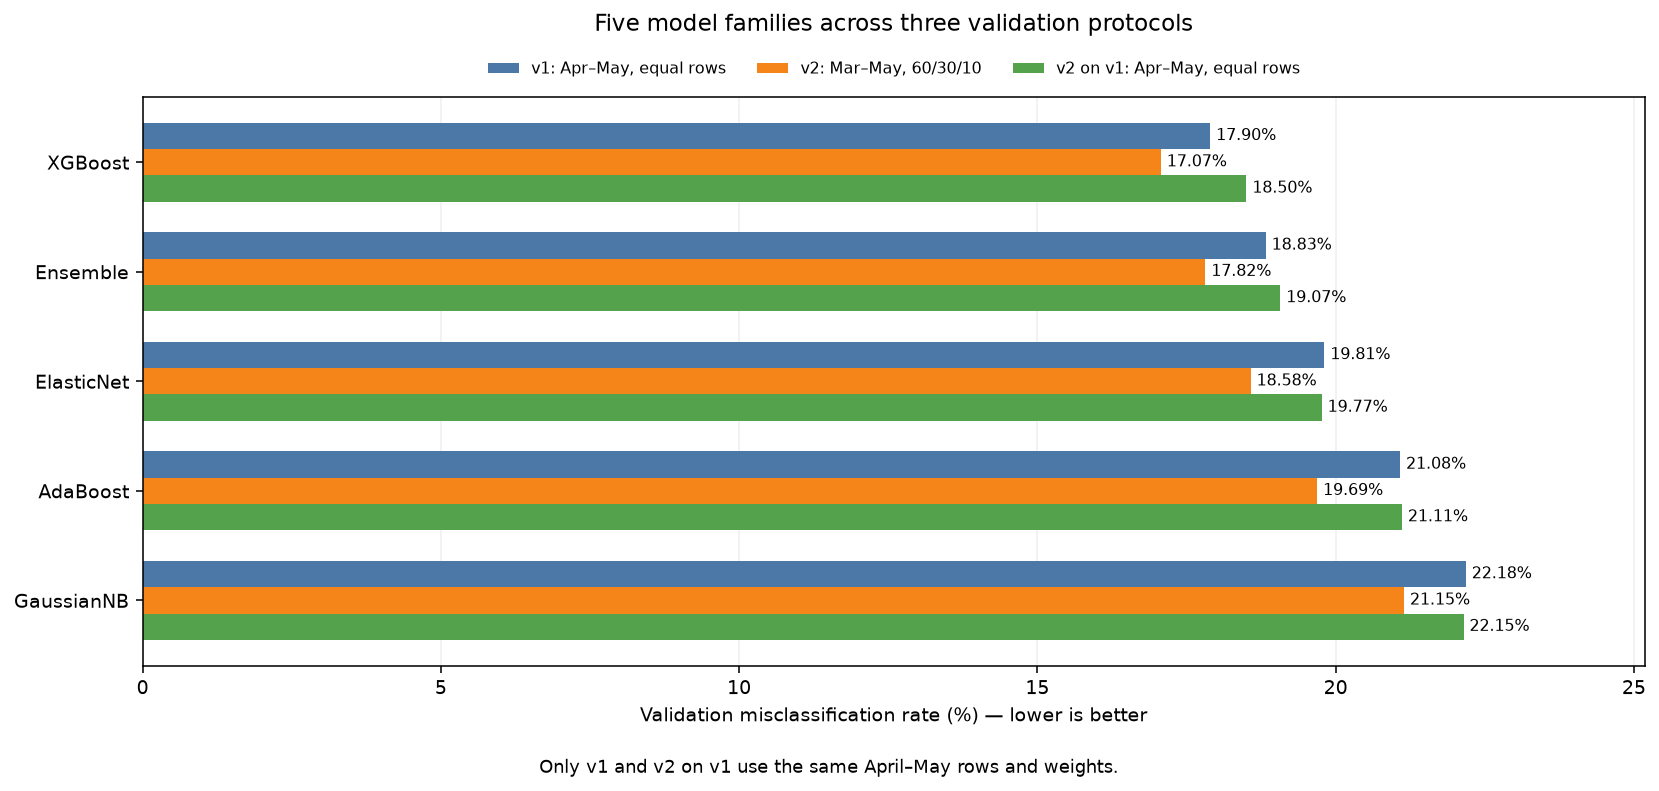

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"v1": "#4C78A8", "v2": "#F58518", "v2 on v1": "#54A24B"}
labels = {
    "v1": "v1: Apr–May, equal rows",
    "v2": "v2: Mar–May, 60/30/10",
    "v2 on v1": "v2 on v1: Apr–May, equal rows",
}
y = np.arange(len(score_pct))
height = 0.24
for offset, case in zip((-height, 0, height), CASE_SPECS):
    values = score_pct[case].to_numpy()
    bars = ax.barh(y + offset, values, height=height, label=labels[case], color=colors[case])
    ax.bar_label(bars, labels=[f"{value:.2f}%" for value in values], padding=3, fontsize=8)
ax.set_yticks(y, score_pct.index)
ax.invert_yaxis()
ax.set_xlim(0, score_pct[list(CASE_SPECS)].to_numpy().max() + 3.0)
ax.set_xlabel("Validation misclassification rate (%) — lower is better")
ax.set_title("Five model families across three validation protocols", pad=34)
ax.xaxis.grid(True, alpha=0.2)
ax.set_axisbelow(True)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3, frameon=False, fontsize=8)
fig.text(0.5, 0.01, "Only v1 and v2 on v1 use the same April–May rows and weights.",
         ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 0.94))
plt.show()